<a href="https://colab.research.google.com/github/Fauzi455/PembelajaranMesin_2026/blob/main/JS-05/TUGAS/Tugas%20Lab-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tugas Lab 1


1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

Saving voice.csv to voice.csv


In [4]:
df = pd.read_csv('voice.csv')
df.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [15]:
X = df.drop('label', axis=1)
y = df['label']

#encoding label: 'male' -> 1, 'female' -> 0
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#pembagian data train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

#standarisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)
y_pred_base = knn_base.predict(X_test_scaled)

print(f"Akurasi Baseline kNN (k=5, 20 Fitur): {accuracy_score(y_test, y_pred_base):.4f}")
print("Laporan Klasifikasi Baseline:")
print()
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

Akurasi Baseline kNN (k=5, 20 Fitur): 0.9763
Laporan Klasifikasi Baseline:

              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

In [17]:
#menguji performa kNN untuk jumlah fitur terbaik dari k=3 hingga 20
feature_counts = range(3, X.shape[1] + 1)
scores_per_k = []

for k_feat in feature_counts:
    selector = SelectKBest(score_func=f_classif, k=k_feat)
    X_train_sel = selector.fit_transform(X_train_scaled, y_train)

    knn_temp = KNeighborsClassifier(n_neighbors=5)
    cv_score = cross_val_score(knn_temp, X_train_sel, y_train, cv=5, scoring='accuracy').mean()
    scores_per_k.append(cv_score)

optimal_num_features = feature_counts[np.argmax(scores_per_k)]
print(f"Jumlah fitur paling optimal berdasarkan ANOVA F-value: {optimal_num_features} fitur.")

#mengambil fitur terpilih
selector_final = SelectKBest(score_func=f_classif, k=optimal_num_features)
selector_final.fit(X_train_scaled, y_train)

selected_features = X.columns[selector_final.get_support()].tolist()
print("\nFitur-fitur yang terpilih:")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

#transformasi dataset ke subset fitur optimal
X_train_opt = selector_final.transform(X_train_scaled)
X_test_opt = selector_final.transform(X_test_scaled)

Jumlah fitur paling optimal berdasarkan ANOVA F-value: 9 fitur.

Fitur-fitur yang terpilih:
1. meanfreq
2. sd
3. median
4. Q25
5. IQR
6. sp.ent
7. sfm
8. centroid
9. meanfun


3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai
k
k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

Nilai k terbaik adalah k = 8 dengan Cross-Validation Accuracy = 0.9795



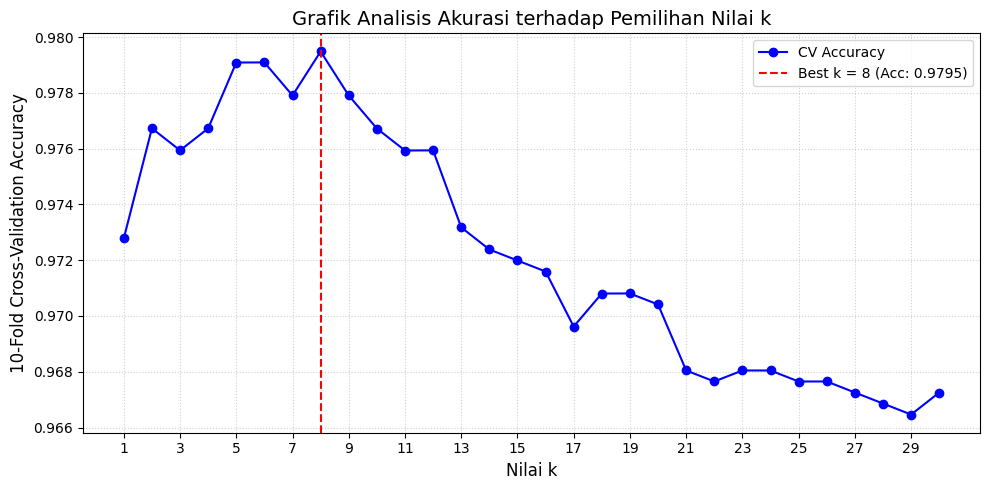

In [21]:
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_opt, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)
print(f"Nilai k terbaik adalah k = {best_k} dengan Cross-Validation Accuracy = {best_cv_score:.4f}")
print()

#evaluasi pada data test dengan k terbaik
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_opt, y_train)
y_pred_final = final_model.predict(X_test_opt)

#visualisasi grafik hubungan nilai k vs akurasi
plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, marker='o', linestyle='-', color='b', label='CV Accuracy')
plt.axvline(best_k, color='r', linestyle='--', label=f'Best k = {best_k} (Acc: {best_cv_score:.4f})')
plt.title('Grafik Analisis Akurasi terhadap Pemilihan Nilai k', fontsize=14)
plt.xlabel('Nilai k', fontsize=12)
plt.ylabel('10-Fold Cross-Validation Accuracy', fontsize=12)
plt.xticks(range(1, 31, 2))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()